<a href="https://colab.research.google.com/github/apurvakumbhar/Deep_Learning/blob/main/DLExperiment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [ ]:
# -------------------- Load & Preprocess MNIST --------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#  Common CNN Model
def create_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

EPOCHS = 10

In [ ]:
# STEP DECAY
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    step_size = 3
    return initial_lr * (drop ** (epoch // step_size))

model_step = create_model()
model_step.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_step = model_step.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=[LearningRateScheduler(step_decay)],
    verbose=1
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.7788 - loss: 0.8656 - val_accuracy: 0.9290 - val_loss: 0.2444 - learning_rate: 0.0100
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.9314 - loss: 0.2299 - val_accuracy: 0.9527 - val_loss: 0.1647 - learning_rate: 0.0100
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9492 - loss: 0.1687 - val_accuracy: 0.9614 - val_loss: 0.1336 - learning_rate: 0.0100
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9609 - loss: 0.1341 - val_accuracy: 0.9656 - val_loss: 0.1150 - learning_rate: 0.0050
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9663 - loss: 0.1159 - val_accuracy: 0.9668 - val_loss: 0.1110 - learning_rate: 0.0050
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9681 - loss: 0.1078 - val_accuracy: 0.9694 - val_loss: 0.1022 - learning_rate: 0.0050
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accura

In [ ]:
#  EXPONENTIAL DECAY
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.9
)

model_exp = create_model()
model_exp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp = model_exp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9243 - loss: 0.2475 - val_accuracy: 0.9711 - val_loss: 0.0992
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.9831 - loss: 0.0559 - val_accuracy: 0.9786 - val_loss: 0.0683
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9914 - loss: 0.0273 - val_accuracy: 0.9826 - val_loss: 0.0752
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.9943 - loss: 0.0190 - val_accuracy: 0.9839 - val_loss: 0.0677
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9842 - val_loss: 0.0760
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.9983 - loss: 0.0047 - val_accuracy: 0.9853 - val_loss: 0.0887
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.9989 - loss: 0.0030 - val_accuracy: 0.9851 - val_loss: 0.0983
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.9996 -

In [ ]:
# REDUCE LR ON PLATEAU
model_plateau = create_model()
model_plateau.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

plateau_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history_plateau = model_plateau.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=[plateau_cb],
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9153 - loss: 0.2879 - val_accuracy: 0.9799 - val_loss: 0.0604 - learning_rate: 0.0010
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9852 - loss: 0.0486 - val_accuracy: 0.9846 - val_loss: 0.0488 - learning_rate: 0.0010
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 25ms/step - accuracy: 0.9900 - loss: 0.0308 - val_accuracy: 0.9838 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9930 - loss: 0.0202 - val_accuracy: 0.9861 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.9857 - val_loss: 0.0436 - learning_rate: 0.0010
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9978 - loss: 0.0076 - val_accuracy: 0.9836 - val_loss: 0.0596 - learning_rate: 0.0010
Epoch 7/10
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

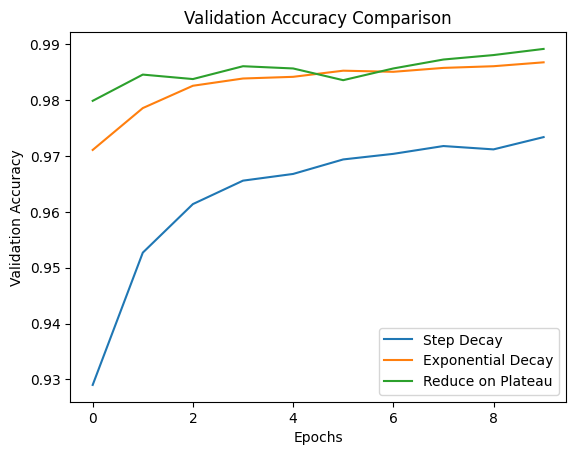

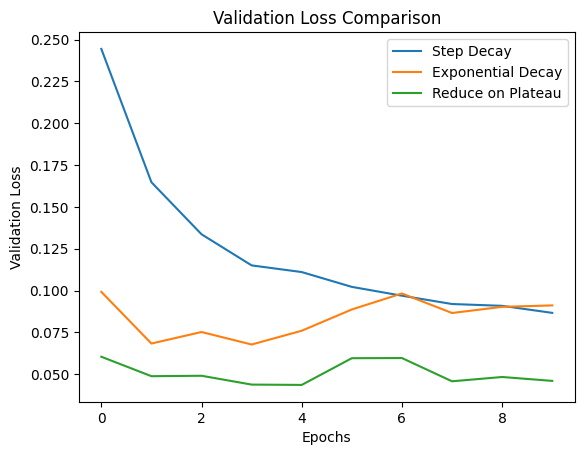

In [ ]:
# Validation Accuracy Plot
plt.figure()
plt.plot(history_step.history['val_accuracy'])
plt.plot(history_exp.history['val_accuracy'])
plt.plot(history_plateau.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend(["Step Decay", "Exponential Decay", "Reduce on Plateau"])
plt.show()

# Validation Loss Plot
plt.figure()
plt.plot(history_step.history['val_loss'])
plt.plot(history_exp.history['val_loss'])
plt.plot(history_plateau.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend(["Step Decay", "Exponential Decay", "Reduce on Plateau"])
plt.show()